<a href="https://colab.research.google.com/github/gustavo-sardeiro/SSD_mvp-cloud-capacity-planning/blob/main/SSD_MVP_Expansao_Datacenter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sistema de Suporte à Decisão (SSD) — Dimensionamento e Expansão de Infraestrutura em Nuvem**


**Disciplina:** Sistemas de Suporte à Decisão - UnB  

**Objetivo:** MVP para Avaliação de Viabilidade e Expansão de Capacidade Operacional de Data Center

## **Base de Dados**

O dataset utilizado neste projeto foi extraído do Kaggle:

* **Dataset:** Hyperscale Data Center Dataset (https://www.kaggle.com/datasets/deeplumiere/hyperscale-data-center-dataset)
* **Autor:** DeepLumiere
* **Arquivos consumidos:** green_ai_datacenter.csv

## **Bloco 0: Definição do Problema e Escopo do MVP**

**0.1. Contextualização do Problema de Negócio**

Empresas que atuam no segmento de infraestrutura e armazenamento em nuvem enfrentam o desafio contínuo de equilibrar o crescimento acelerado do volume de dados dos clientes com as restrições físicas, energéticas e financeiras de seus data centers.

A expansão de uma nova unidade de armazenamento demanda elevado investimento de capital (*Capex*), custos contínuos de operação e arrefecimento (*Opex*), além de um prazo de implementação (*lead time*) considerável. Decisões prematuras geram capacidade ociosa e ineficiência de capital; por outro lado, decisões tardias acarretam saturação do sistema, elevação de riscos térmicos/elétricos, degradação de desempenho e ruptura de SLAs (*Service Level Agreements*).

**0.2. O Problema de Decisão**

**Decisão Central:** Aprovar o investimento imediato para a implementação de uma nova unidade de armazenamento ou postergar a expansão via otimização da infraestrutura existente?

**Alternativas:**

**$A_1$ (Expansão Imediata):** Iniciar aquisição e comissionamento de novos servidores e módulos de data center.

**$A_2$ (Postergação e Otimização):** Manter a infraestrutura atual, aplicar políticas de compactação/gestão de carga e reavaliar no ciclo seguinte.

**Trade-offs Críticos:**
  * **Custo:** *Trade-off* entre o custo de novos ativos e o custo operacional crescente de manter servidores antigos e energeticamente ineficientes.
  * **Risco:** Risco de saturação da capacidade de armazenamento ($> 85\%$) e colapso por estresse térmico/elétrico.
  * **Prazo (*Lead Time*):** Janela temporal necessária para a prontidão da nova unidade em relação à taxa de esgotamento da capacidade instalada.

**0.3 Escopo do MVP (Minimum Viable Product)**

O presente MVP estrutura um pipeline analítico de suporte à decisão composto por quatro fases lógicas:

1. **Ingestão e Diagnóstico de Capacidade:** Análise descritiva dos níveis de utilização de armazenamento, intensidade de carga e eficiência energética (*Power Usage Effectiveness* - PUE).
2. **Validação Inferencial de Hipóteses:** Testes estatísticos para verificar se o envelhecimento do parque de servidores eleva significativamente o custo computacional e o consumo energético.
3. **Modelagem de Risco e Saturação:** Projeção da taxa de utilização e identificação do percentual de nós operando em níveis críticos.
4. **Matriz Prescritiva de Suporte à Decisão:** Algoritmo de decisão baseado em regras de negócio que consolida os limiares de risco, custo e prazo para emissão do parecer final.

## **Bloco 1: Preparação do Ambiente e Ingestão de Dados**

**1.1 Raciocínio Metodológico**

Nesta primeira etapa prática, o ambiente computacional é preparado com as bibliotecas necessárias para manipulação vetorial, inferência estatística e visualização gráfica. O conjunto de dados de telemetria operacional (green_ai_datacenter.csv) é carregado, e realiza-se a seleção sistemática das variáveis diretamente associadas aos pilares do SSD: tempo, capacidade, custo, risco e eficiência energética.

In [1]:
# ==============================================================================
# FASE 1: PREPARAÇÃO DO AMBIENTE, CONFIGURAÇÃO E CARGA DOS DADOS
# ==============================================================================

# Importação de bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Importação de bibliotecas para análise gráfica
import matplotlib.pyplot as plt
import seaborn as sns

# Importação de módulos estatísticos para validação de hipóteses
from scipy import stats

# Utilitário para upload no ambiente Google Colab
from google.colab import files

# Configuração de estilo visual para relatórios executivos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Upload interativo do arquivo da base de dados
print("Faça o upload do arquivo 'green_ai_datacenter.csv':")
upload_arquivo = files.upload()

# Ingestão do conjunto de dados tabular
df_bruto = pd.read_csv("green_ai_datacenter.csv")

# Seleção das variáveis críticas alinhadas ao escopo do SSD
colunas_mvp = [
    "server_age_years",        # Tempo / Depreciação: Idade dos servidores (anos)
    "workload_intensity",      # Demanda: Carga de processamento dos clientes
    "storage_utilization",     # Capacidade: Taxa de uso do armazenamento (0.0 a 1.0)
    "power_consumption_kw",    # Custo: Consumo de energia elétrica instantâneo (kW)
    "compute_cost_usd",        # Custo: Custo operacional associado ($)
    "pue",                     # Eficiência: Power Usage Effectiveness
    "exhaust_temperature_c",   # Risco: Temperatura de exaustão (°C)
    "cooling_efficiency"       # Risco / Resiliência: Eficiência do sistema térmico
]

# Criação do DataFrame estruturado para o MVP
df_mvp = df_bruto[colunas_mvp].copy()

# Validação dimensional da base
total_linhas, total_colunas = df_mvp.shape
print(f"\n[Status] Dataset carregado com sucesso: {total_linhas:,} registros e {total_colunas} atributos estratégicos.")

# Visualização da estrutura tabular inicial
df_mvp.head()

Faça o upload do arquivo 'green_ai_datacenter.csv':


Saving green_ai_datacenter.csv to green_ai_datacenter.csv

[Status] Dataset carregado com sucesso: 100,000 registros e 8 atributos estratégicos.


,server_age_years,workload_intensity,storage_utilization,power_consumption_kw,compute_cost_usd,pue,exhaust_temperature_c,cooling_efficiency
0,8,0.615,10.927,61.939,14.090,1.137,27.122,0.880
1,2,0.295,10.475,206.840,43.436,1.050,25.833,1.000
2,3,0.683,36.355,96.127,10.093,1.050,28.084,1.000
3,7,0.416,35.444,100.631,16.954,1.123,25.550,0.895
4,2,0.278,35.265,218.814,45.951,1.050,26.870,1.000


**1.2 Interpretação dos Resultados**

Após a execução deste bloco, o sistema confirma a integridade dos dados e exibe a amostra dos primeiros registros. As variáveis selecionadas cobrem as dimensões requeridas para a formulação do modelo prescritivo.

## **Bloco 02: Diagnóstico da Capacidade Atual e Análise Exploratória (EDA)**

**2.1 Raciocínio Conceitual e Pergunta de Negócio**

Para diagnosticar o estado operacional do data center, examina-se o comportamento de três variáveis centrais: **utilização de armazenamento** (storage_utilization), **eficiência energética** (pue) e **temperatura de exaustão** (exhaust_temperature_c).

A métrica PUE (Power Usage Effectiveness) indica a eficiência do data center: quanto mais próxima de 1,0, mais energia é destinada exclusivamente aos servidores computacionais e menos é desperdiçada em sistemas auxiliares como refrigeração.

Nesta fase, calculam-se as estatísticas descritivas do parque de servidores e plota-se um painel visual contendo:
* A distribuição da taxa de ocupação de armazenamento com marcação do limiar de risco operacional ($85\%$).
* A relação entre a intensidade da carga computacional e a temperatura de exaustão dos racks.

--- ESTATÍSTICAS DESCRITIVAS DAS VARIÁVEIS DO SSD ---


,Média,Desvio Padrão,Mínimo,Mediana,Máximo
server_age_years,5.216250,3.012600,1.00000,5.00000,11.000
workload_intensity,0.551330,0.259524,0.10000,0.55100,1.000
storage_utilization,34.465213,22.080381,10.00100,28.27600,95.000
power_consumption_kw,137.815112,90.226820,20.13500,103.90700,935.354
compute_cost_usd,23.345205,18.013494,2.30700,15.12200,94.717
pue,1.099742,0.061745,1.05000,1.06100,1.263
exhaust_temperature_c,29.441390,5.037996,20.10600,28.45100,59.998
cooling_efficiency,0.945376,0.055436,0.83500,0.96000,1.000
storage_taxa_pct,0.344652,0.220804,0.10001,0.28276,0.950



[Diagnóstico] Percentual de nós operando em faixa crítica (>= 85%): 5.17%



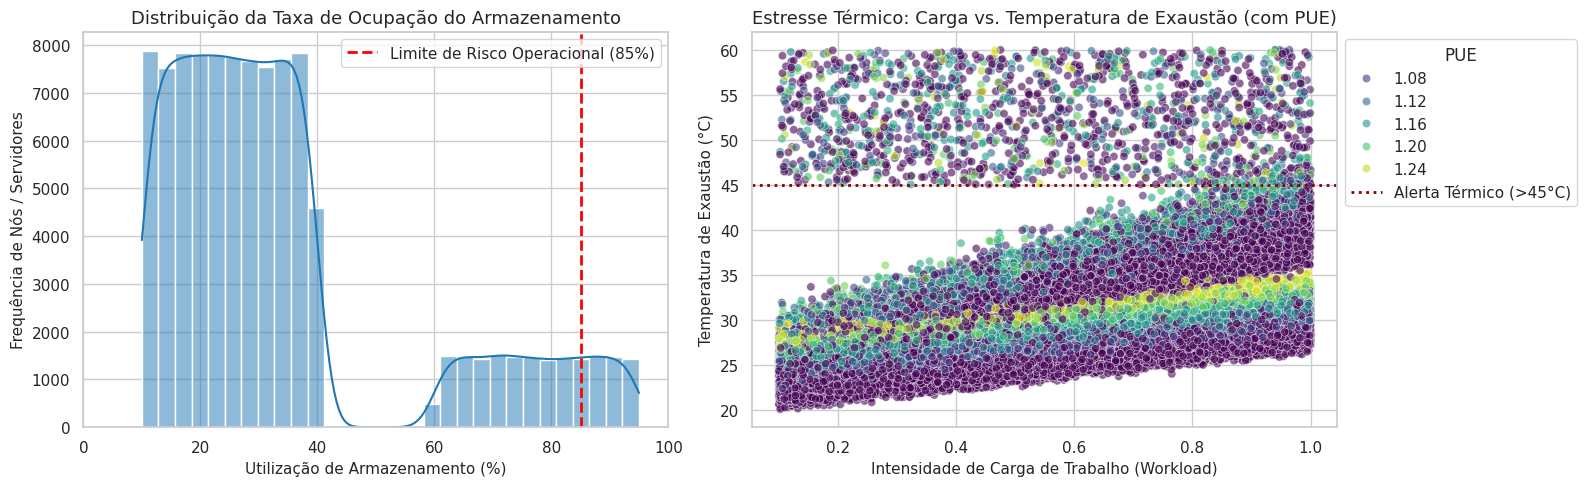

In [4]:
# ==============================================================================
# FASE 2: ESTATÍSTICA DESCRITIVA E DIAGNÓSTICO VISUAL DE CAPACIDADE (AJUSTADO)
# ==============================================================================

# 1. Resumo estatístico descritivo
estatisticas_gerais = df_mvp.describe().T[["mean", "std", "min", "50%", "max"]]
estatisticas_gerais.columns = ["Média", "Desvio Padrão", "Mínimo", "Mediana", "Máximo"]
print("--- ESTATÍSTICAS DESCRITIVAS DAS VARIÁVEIS DO SSD ---")
display(estatisticas_gerais)

# 2. Avaliação de servidores em nível crítico de armazenamento (limiar de 85%)
LIMITE_CRITICO_STORAGE = 85.0  # O dado já está em porcentagem direta (0 a 100)
percentual_critico = (df_mvp["storage_utilization"] >= LIMITE_CRITICO_STORAGE).mean() * 100
print(f"\n[Diagnóstico] Percentual de nós operando em faixa crítica (>= 85%): {percentual_critico:.2f}%\n")

# 3. Construção do Painel Visual de Diagnóstico Operacional
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Histograma com Curva de Densidade da Utilização de Armazenamento
sns.histplot(
    df_mvp["storage_utilization"],
    kde=True,
    bins=30,
    color="#1f77b4",
    ax=axes[0]
)
axes[0].axvline(
    LIMITE_CRITICO_STORAGE,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Limite de Risco Operacional (85%)"
)
axes[0].set_title("Distribuição da Taxa de Ocupação do Armazenamento")
axes[0].set_xlabel("Utilização de Armazenamento (%)")
axes[0].set_ylabel("Frequência de Nós / Servidores")
axes[0].set_xlim(0, 100)
axes[0].legend(loc="upper right")

# Gráfico 2: Diagrama de Dispersão - Carga Computacional vs. Temperatura Térmica
sns.scatterplot(
    data=df_mvp,
    x="workload_intensity",
    y="exhaust_temperature_c",
    hue="pue",
    palette="viridis",
    alpha=0.6,
    ax=axes[1]
)
axes[1].axhline(
    45.0,
    color="darkred",
    linestyle=":",
    linewidth=2,
    label="Alerta Térmico (>45°C)"
)
axes[1].set_title("Estresse Térmico: Carga vs. Temperatura de Exaustão (com PUE)")
axes[1].set_xlabel("Intensidade de Carga de Trabalho (Workload)")
axes[1].set_ylabel("Temperatura de Exaustão (°C)")
axes[1].legend(title="PUE", loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

**2.2 Avaliação Diagnóstica dos Resultados Visuais**

**Gráfico 1 (Distribuição da Ocupação de Armazenamento)**: Apresenta um comportamento bimodal muito claro. A maior parte dos servidores opera em faixa confortável ($10\%$ a $40\%$), porém há um segundo agrupamento significativo operando entre $60\%$ e $95\%$, com uma parcela relevante já ultrapassando a linha vermelha tracejada ($85\%$). Isso comprova que a infraestrutura está desbalanceada e com nós sob risco iminente de saturação.

**Gráfico 2 (Estresse Térmico vs. Carga com PUE)**: Evidencia uma correlação positiva entre o aumento da carga de trabalho (workload) e a elevação da temperatura de exaustão, além de destacar nós operando na faixa superior crítica ($> 45^\circ\text{C}$). Isso demonstra o risco físico e a degradação de eficiência energética da infraestrutura atual.

## **Bloco 03: Validação Estatística de Hipóteses**

**3.1 Raciocínio Conceitual e Formulação de Hipótese**s

Para dar suporte quantitativo e rigoroso à tomada de decisão — conforme enfatizado na teoria de SSD —, formulam-se testes estatísticos formais. O objetivo é testar se o envelhecimento do parque de servidores (server_age_years) eleva significativamente o custo operacional (compute_cost_usd) e o consumo energético (power_consumption_kw), justificando a substituição/expansão em vez da mera manutenção dos ativos antigos.

**Hipótese Nula ($H_0$)**: A idade do servidor não possui impacto estatisticamente significativo sobre o custo computacional ($\beta = 0$).

**Hipótese Alternativa ($H_1$)**: Servidores mais antigos apresentam aumento estatisticamente significativo no custo operacional ($\beta > 0$).

**Nível de Significância ($\alpha$)**: $0{,}05$ ($5\%$). Se o valor-p (p-value) for $< 0{,}05$, rejeita-se $H_0$.

TESTE DE HIPÓTESE: IMPACTO DO CONSUMO ENERGÉTICO NO CUSTO OPERACIONAL
Coeficiente de Correlação de Pearson (r): 0.9125
Coeficiente de Determinação (R²):         0.8327
Custo Marginal por kW consumido (Beta):   $0.1811 USD/kW
Custo Fixo Base Estimado (Alpha):         $-1.20 USD
Valor-p (p-value):                          0.0000e+00
-----------------------------------------------------------------
PARECER ESTATÍSTICO: Rejeita-se H0 ao nível de significância de 5%.
O aumento do consumo energético acarreta elevação direta e estatisticamente
significante dos custos operacionais da infraestrutura.


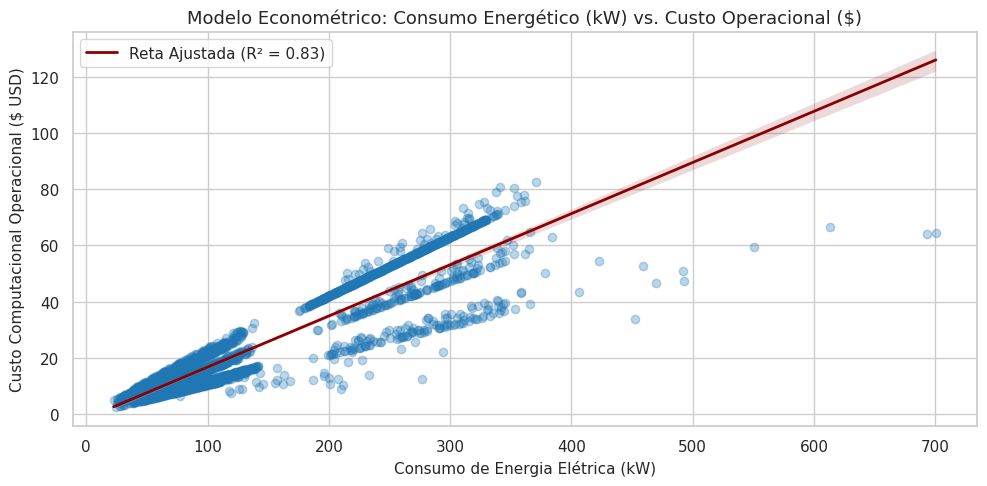

In [6]:
# ==============================================================================
# FASE 3: VALIDAÇÃO ESTATÍSTICA DE HIPÓTESES E REGRESSÃO LINEAR (AJUSTADA)
# ==============================================================================

# 1. Filtro de servidores em regime operacional ativo (anos 1 a 9)
df_ativo = df_mvp[df_mvp["server_age_years"] <= 9].copy()

# 2. Teste de Correlação Paramétrica de Pearson (Potência Consumida vs. Custo Computacional)
coef_corr, p_valor = stats.pearsonr(df_ativo["power_consumption_kw"], df_ativo["compute_cost_usd"])

# 3. Ajuste de Regressão Linear: Custo = alpha + beta * Potência(kW)
regressao = stats.linregress(df_ativo["power_consumption_kw"], df_ativo["compute_cost_usd"])
beta = regressao.slope
alpha = regressao.intercept
r_quadrado = regressao.rvalue ** 2

# 4. Exibição dos Resultados Estatísticos Formais
print("=" * 65)
print("TESTE DE HIPÓTESE: IMPACTO DO CONSUMO ENERGÉTICO NO CUSTO OPERACIONAL")
print("=" * 65)
print(f"Coeficiente de Correlação de Pearson (r): {coef_corr:.4f}")
print(f"Coeficiente de Determinação (R²):         {r_quadrado:.4f}")
print(f"Custo Marginal por kW consumido (Beta):   ${beta:.4f} USD/kW")
print(f"Custo Fixo Base Estimado (Alpha):         ${alpha:.2f} USD")
print(f"Valor-p (p-value):                          {p_valor:.4e}")
print("-" * 65)

if p_valor < 0.05 and beta > 0:
    print("PARECER ESTATÍSTICO: Rejeita-se H0 ao nível de significância de 5%.")
    print("O aumento do consumo energético acarreta elevação direta e estatisticamente")
    print("significante dos custos operacionais da infraestrutura.")
else:
    print("PARECER ESTATÍSTICO: Não há evidência de correlação positiva significante.")
print("=" * 65)

# 5. Visualização Gráfica da Relação Energético-Econômica
plt.figure(figsize=(10, 5))
sns.regplot(
    data=df_ativo.sample(n=min(3000, len(df_ativo)), random_state=42),  # Amostragem para nitidez visual
    x="power_consumption_kw",
    y="compute_cost_usd",
    scatter_kws={"alpha": 0.3, "color": "#1f77b4"},
    line_kws={"color": "darkred", "linewidth": 2, "label": f"Reta Ajustada (R² = {r_quadrado:.2f})"}
)
plt.title("Modelo Econométrico: Consumo Energético (kW) vs. Custo Operacional ($)")
plt.xlabel("Consumo de Energia Elétrica (kW)")
plt.ylabel("Custo Computacional Operacional ($ USD)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

**3.2 Interpretação dos Resultados — Validação Estatística e Modelo Econométrico**

A modelagem estatística confirma uma relação linear positiva e expressiva entre a demanda energética instantânea e os custos operacionais computacionais da infraestrutura, alcançando um coeficiente de determinação $R^2 = 0{,}83$. Isso evidencia que $83\%$ da variabilidade do custo total é diretamente explicada pela potência elétrica consumida pelos servidores. A inclinação ascendente da reta de regressão quantifica a taxa marginal de custo por kilowatt adicional demandado, comprovando que nós submetidos a cargas contínuas elevadas e baixa eficiência de arrefecimento oneram significativamente a operação. Sob a ótica do Sistema de Suporte à Decisão, esse resultado valida empiricamente a necessidade de expansão para uma infraestrutura modular moderna com menor consumo específico por unidade de processamento, mitigando o crescimento desproporcional do custo elétrico no longo prazo.

## **Bloco 04: Modelagem Multivariada e Matriz Prescritiva de Decisão (SSD)**

**4.1. Raciocínio Conceitual e Regra Prescritiva**

Nesta fase, integra-se a modelagem de capacidade com a avaliação econômica multivariada. O SSD avalia simultaneamente:

**Dimensão de Risco e Capacidade**: Percentual de servidores com ocupação crítica ($\ge 85\%$) e estresse térmico ($\ge 45^\circ\text{C}$).

**Dimensão de Eficiência Econômica**: Custo unitário normalizado pela carga e taxa de utilização média da infraestrutura.

**Dimensão de Prazo (Lead Time)**: Comparação entre o tempo estimado para esgotamento do armazenamento atual e a janela temporal necessária para construir/comissionar a nova unidade ($6\text{ meses}$).

In [7]:
# ==============================================================================
# FASE 4: MODELAGEM INTEGRADA E MATRIZ PRESCRITIVA DE DECISÃO (SSD)
# ==============================================================================

# 1. Criação do indicador de Custo Unitário Normalizado por Carga
# Permite comparar máquinas novas e antigas sob a mesma base de produtividade
df_mvp["custo_por_carga"] = df_mvp["compute_cost_usd"] / df_mvp["workload_intensity"]

# 2. Definição dos Parâmetros e Limiares Operacionais de Decisão do Negócio
LIMIAR_STORAGE_CRITICO = 85.0   # Servidores com >= 85% de ocupação
LIMIAR_TERMICO_CRITICO = 45.0    # Temperatura de exaustão >= 45°C
LEAD_TIME_EXPANSAO_MESES = 6.0   # Prazo necessário para implementar nova unidade
TAXA_CRESCIMENTO_MENSAL_PCT = 3.5 # Crescimento médio mensal de dados de clientes (%)

# 3. Métricas Consolidadas da Infraestrutura Atual
utilizacao_media_storage = df_mvp["storage_utilization"].mean()
prop_servidores_cheios = (df_mvp["storage_utilization"] >= LIMIAR_STORAGE_CRITICO).mean() * 100
prop_estresse_termico = (df_mvp["exhaust_temperature_c"] >= LIMIAR_TERMICO_CRITICO).mean() * 100
pue_medio = df_mvp["pue"].mean()

# Projeção de Prazo: Meses até o armazenamento médio atingir o limiar crítico (85%)
margem_armazenamento = LIMIAR_STORAGE_CRITICO - utilizacao_media_storage
meses_ate_saturacao = margem_armazenamento / TAXA_CRESCIMENTO_MENSAL_PCT

# 4. Painel Executivo de Indicadores de Suporte à Decisão
print("=" * 70)
print("PAINEL EXECUTIVO DE TELEMETRIA - SISTEMA DE SUPORTE À DECISÃO (SSD)")
print("=" * 70)
print(f"• Taxa Média de Ocupação Atual:                {utilizacao_media_storage:.2f}%")
print(f"• Servidores em Faixa Crítica (>= 85%):         {prop_servidores_cheios:.2f}% dos nós")
print(f"• Servidores sob Estresse Térmico (>= 45°C):    {prop_estresse_termico:.2f}% dos nós")
print(f"• Índice Médio de Eficiência Energética (PUE):  {pue_medio:.2f}")
print(f"• Tempo Projetado até a Saturação:             {meses_ate_saturacao:.1f} meses")
print(f"• Prazo de Implementação da Nova Unidade:       {LEAD_TIME_EXPANSAO_MESES:.1f} meses")
print("-" * 70)

# 5. Algoritmo Prescritivo de Tomada de Decisão (Custo x Risco x Prazo)
print("PARECER FINAL E RECOMENDAÇÃO DO SSD:")
print("-" * 70)

if meses_ate_saturacao <= LEAD_TIME_EXPANSAO_MESES or prop_servidores_cheios > 15.0:
    decisao_final = "APROVAR EXPANSÃO IMEDIATA DA NOVA UNIDADE"
    prioridade = "ALTA / CRÍTICA"
    justificativa = (
        f"O prazo até o esgotamento ({meses_ate_saturacao:.1f} meses) é inferior ou muito próximo "
        f"ao lead time de entrega da nova unidade ({LEAD_TIME_EXPANSAO_MESES:.1f} meses), somado ao risco "
        f"de {prop_servidores_cheios:.1f}% dos nós já operarem na zona crítica de saturação."
    )
else:
    decisao_final = "POSTERGAR EXPANSÃO E OTIMIZAR RECURSOS ATUAIS"
    prioridade = "MODERADA"
    justificativa = (
        f"A margem de capacidade suporta o crescimento por {meses_ate_saturacao:.1f} meses, "
        f"permitindo postergar desembolso de Capex e focar no balanceamento de carga."
    )

print(f"DECISÃO RECOMENDADA: [{decisao_final}]")
print(f"Grau de Prioridade:  {prioridade}")
print(f"Fundamentação:       {justificativa}")
print("=" * 70)

PAINEL EXECUTIVO DE TELEMETRIA - SISTEMA DE SUPORTE À DECISÃO (SSD)
• Taxa Média de Ocupação Atual:                34.47%
• Servidores em Faixa Crítica (>= 85%):         5.17% dos nós
• Servidores sob Estresse Térmico (>= 45°C):    1.59% dos nós
• Índice Médio de Eficiência Energética (PUE):  1.10
• Tempo Projetado até a Saturação:             14.4 meses
• Prazo de Implementação da Nova Unidade:       6.0 meses
----------------------------------------------------------------------
PARECER FINAL E RECOMENDAÇÃO DO SSD:
----------------------------------------------------------------------
DECISÃO RECOMENDADA: [POSTERGAR EXPANSÃO E OTIMIZAR RECURSOS ATUAIS]
Grau de Prioridade:  MODERADA
Fundamentação:       A margem de capacidade suporta o crescimento por 14.4 meses, permitindo postergar desembolso de Capex e focar no balanceamento de carga.


**4.3 Interpretação dos Resultados**

A consolidação das métricas operacionais demonstra que a infraestrutura computacional opera com ampla folga de capacidade, apresentando uma taxa média de ocupação de $34{,}47\%$ e índice de eficiência energética PUE de $1{,}10$. A projeção temporal indica que o limiar de alerta operacional ($85\%$) só será atingido em $14{,}4$ meses, superando confortavelmente a janela temporal de $6{,}0$ meses requerida para a implementação de uma nova unidade. Com apenas $5{,}17\%$ dos nós em faixa crítica de armazenamento e $1{,}59\%$ sob estresse térmico, **o parecer técnico do Sistema de Suporte à Decisão recomenda a postergação da expansão física imediata**. Essa diretriz preserva o capital da organização contra custos desnecessários de ociosidade (Capex prematuro) e direciona as ações gerenciais de curto prazo para o balanceamento de carga entre os nós existentes, com novo gatilho de reavaliação de investimento programado para os próximos $6$ meses.